In [1]:
import cupy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import importlib
import sys
sys.path.append('..')
import collision_cp
importlib.reload(collision_cp)
from collision_cp import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

In [2]:
# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

# define properties of molecules
reduced_masses = {"NaKNaK" : 62 / 2, "RbKRb" : 87 * (87 + 40) / (87 + 87 + 40)}     # amu
van_der_wall_coeffs = {"NaKNaK" : 561070, "RbKRb" : 8000}      # a.u.

molecules = "RbCsRbCs"
mu = 51 / e_mass      # now in a.u.
c6 = 7700         # a.u.

abar = (np.pi * 2 ** (-3/2) / math.gamma(5/4) / math.gamma(1/2)) ** 2
print(np.pi ** 2 * abar ** 2)

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 2 * np.pi / E_beta    # time
print("reduced mass", mu)
print("C6", c6)
print("beta (a0)", beta)
print("abar (a0)", beta * abar)
print("E_beta (uK)", E_beta * t0 * 1e6)
print("tau_beta (s)", tau_beta * tau0)

print("Time Delay", 1.17 * abar * beta * 5.3e-11 * np.sqrt(2 * mu * 9.1e-31 / np.pi / (E_beta * t0 * 1.38e-23)))
print(1.17 * abar / np.sqrt(np.pi) * tau0 / E_beta)

2.254940993669586
reduced mass 92967.31280765879
C6 7700
beta (a0) 194.51932314094483
abar (a0) 92.97805735595517
E_beta (uK) 44.88404310178714
tau_beta (s) 1.0692536510917182e-06
Time Delay 5.376288522309225e-08
5.369446471230008e-08


In [5]:
print(2 * abar / np.sqrt(np.pi * 0.01))
print(2 * abar / np.sqrt(np.pi * 1) * tau_beta * tau0)
print(tau_beta * tau0 * 80)
print(0.39e-3 / 1e5 * 10 ** 5)
print(0.39e-3 / 1e5 * 10 ** 5 / (tau_beta * tau0 * 80))

5.393526011883793
5.7670473804649e-07
8.554029208733746e-05
0.00039
4.559254948554609


In [20]:
num_samples = 5000

scale = 1

# properties of resonant spectrum
rrkm = 0.39e-3 / 1e5     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos / scale
print("mean spacing (E6)", mean_spacing)
print("mean spacing (mK)", mean_spacing * E_beta * t0 * 1e3)

# thermal properties
temp = 0.01 / scale       # in terms of E6
num_resonances = 1000        # should be odd
print("T/d", temp / mean_spacing)

rrkm_c6 = 2 * np.pi / mean_spacing 
print("RRKM (tau_beta)", rrkm_c6)
print("RRKM (s)", rrkm_c6 * tau_beta * tau0 / scale)

mean spacing (E6) 274.16760284403034
mean spacing (mK) 12.305750503165116
T/d 3.6474039588436875e-05
RRKM (tau_beta) 0.02291731496355531
RRKM (s) 2.450442269800038e-08


In [7]:
mean_x = 0.001
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)

energy_grid = np.linspace(0, 10 * temp, 50000)[1:]
dE = energy_grid[1] - energy_grid[0]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
print(np.sum(time_delays).item())
while np.sum(time_delays).item() < 0 and False:
    energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
    time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
    # print(np.sum(time_delays).item())

-5.664856807013702


In [8]:
import pickle
# with open("sparse_spectrum.pkl", "wb") as f:
#     pickle.dump((energy_GOE_mat, W_mat, x_actual), f)

with open("sparse_spectrum.pkl", "rb") as f:
    energy_GOE_mat, W_mat, x_actual = pickle.load(f)

In [27]:
energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
energy = min(energy_GOE_mat[energy_GOE_mat > 0])

energy_GOE_mat = energy_GOE_mat - energy + 0.005

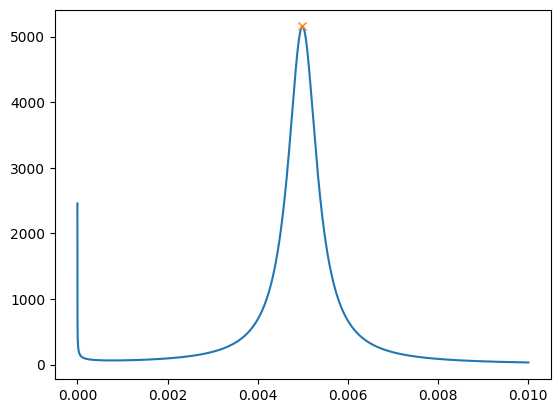

49999
0.00499089981799636


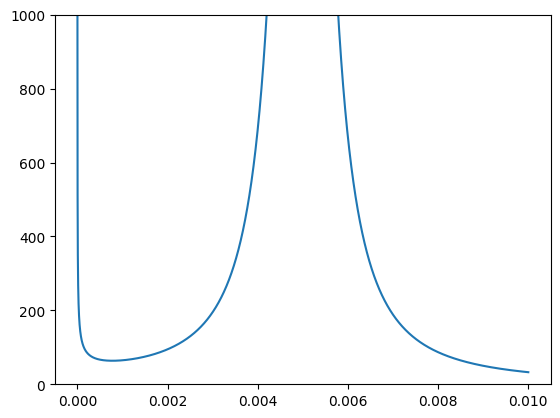

287.585936410779
12548.849499521124
0.30750231250985616


In [31]:
from scipy.signal import find_peaks

energy_grid = np.linspace(0, 0.01, 50000)[1:]
dE = energy_grid[1] - energy_grid[0]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))

peaks, _ = find_peaks(time_delays.get(), height=100)
plt.plot(energy_grid.get(), time_delays.get())
plt.plot(energy_grid[peaks].get(), time_delays[peaks].get(), "x")
# plt.plot(energy_grid.get(), relative_MB_weights(temp, energy_grid).get() * np.max(peaks) * 10)
# plt.xlim(0, 2)
# plt.ylim(0, 5000)
plt.show()

# break

new_energies = energy_grid

# new_energies = np.array([])
# peak_vals = energy_grid[peaks]
# print(len(peaks))
# insert = np.array([i * dE / 500 for i in range(500)])
# for energy in energy_grid:
#     near_peak = False

#     if len(peak_vals) > 0:
#         diff = np.abs(energy - peak_vals)
#         if np.min(diff) < 3 * dE:
#             near_peak = True

#     if near_peak:
#         new_energies = np.append(new_energies, energy + insert)
#     else:
#         new_energies = np.append(new_energies, energy)

print(len(new_energies))
# new_energies = np.array(new_energies)

new_time_delays = wigner_smith_matrix(new_energies, energy_GOE_mat, np.square(W_mat))
print(new_energies[np.argmax(new_time_delays)])
plt.plot(new_energies.get(), new_time_delays.get())
plt.ylim(0, 1000)
# plt.xlim(0, 2)
plt.show()

thermal_delay = dE * relative_MB_weights(temp, energy_grid) * wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
print(np.sum(thermal_delay))
print(np.sum(thermal_delay) / rrkm_c6)
print(np.sum(thermal_delay) * tau_beta * tau0 * 1e3)

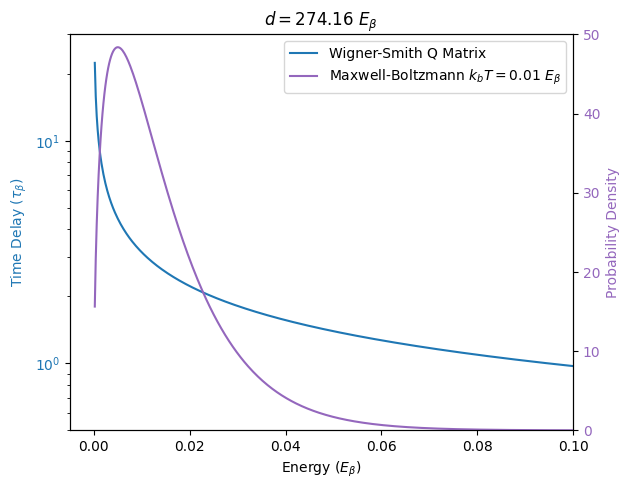

In [34]:
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel(r"Energy ($E_\beta$)")
ax1.set_ylabel(r'Time Delay ($\tau_\beta$)', color=color)
lns1 = ax1.semilogy(new_energies.get(), np.abs(new_time_delays).get(), label=r"Wigner-Smith Q Matrix", color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0.5, 30)
ax1.set_xlim(-0.05, 3)
ax1.set_xlim(-0.005, 0.1)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:purple'
ax2.set_ylabel('Probability Density', color=color)  # we already handled the x-label with ax1
lns2 = ax2.plot(new_energies.get(), relative_MB_weights(0.01, new_energies).get(), label=r"Maxwell-Boltzmann $k_bT = 0.01\ E_\beta$", color=color)
# lns3 = ax2.plot(new_energies.get(), relative_MB_weights(0.01, new_energies).get(), label=r"Maxwell-Boltzmann $k_bT = 0.01 E_\beta$", color="orange")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 1)
ax2.set_ylim(0, 50)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
ax1.set_title(r"$d = $" + str(mean_spacing)[0:6] + r" $E_\beta$")
lns = lns1+lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs,loc="upper right")
# plt.savefig(f"x={str(mean_x)}.pdf")
plt.savefig(f"sparse_spectrum_T=0.01.png", bbox_inches='tight')
plt.show()

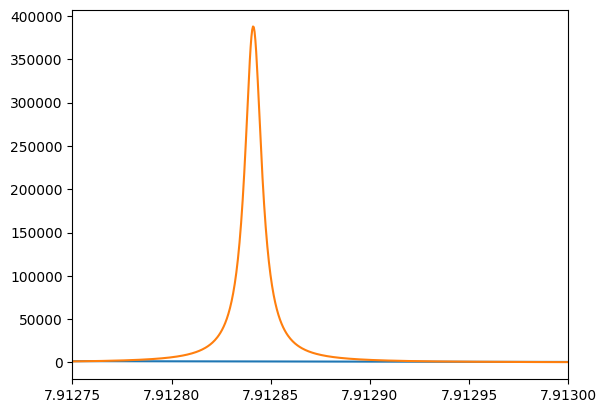

In [137]:
plt.plot(energy_grid.get(), time_delays.get())
plt.plot(new_energies.get(), new_time_delays.get())
plt.xlim(7.91275, 7.913)
plt.show()

In [98]:
thermal_delay = dE * relative_MB_weights(temp, energy_grid) * wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
print(np.sum(thermal_delay))

spacing = np.append(new_energies[1:] - new_energies[:-1], dE)
new_thermal_delay = spacing * relative_MB_weights(temp, new_energies) * wigner_smith_matrix(new_energies, energy_GOE_mat, np.square(W_mat))
print(np.sum(new_thermal_delay))

60.978047107560435
61.6348789328186


In [5]:
normal = []
new = []

for num_energies in np.arange(30000, 40000, 1000):

    energy_grid = np.linspace(0, 10 * temp, num_energies.item())[1:]
    dE = energy_grid[1] - energy_grid[0]
    time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))

    peaks, _ = find_peaks(time_delays.get(), height=100)

    new_energies = np.array([])
    peak_vals = energy_grid[peaks]

    insert = np.array([i * dE / 100 for i in range(100)])

    for energy in energy_grid:
        near_peak = False

        diff = np.abs(energy - peak_vals)
        if np.min(diff) < 3 * dE:
            near_peak = True

        if near_peak:
            new_energies = np.append(new_energies, energy + insert)
        else:
            new_energies = np.append(new_energies, energy)

    print(len(new_energies))
    # new_energies = np.array(new_energies)

    new_time_delays = wigner_smith_matrix(new_energies, energy_GOE_mat, np.square(W_mat))
    
    
    thermal_delay = dE * relative_MB_weights(temp, energy_grid) * wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
    normal.append(np.sum(thermal_delay))

    spacing = np.append(new_energies[1:] - new_energies[:-1], dE)
    new_thermal_delay = spacing * relative_MB_weights(temp, new_energies) * wigner_smith_matrix(new_energies, energy_GOE_mat, np.square(W_mat))
    new.append(np.sum(new_thermal_delay))

NameError: name 'find_peaks' is not defined

[array(95.16165976), array(95.21318459), array(95.5307995), array(95.19881295), array(95.32954396), array(95.58193585), array(95.17480707), array(95.14827969), array(95.42421443), array(95.44125306)]


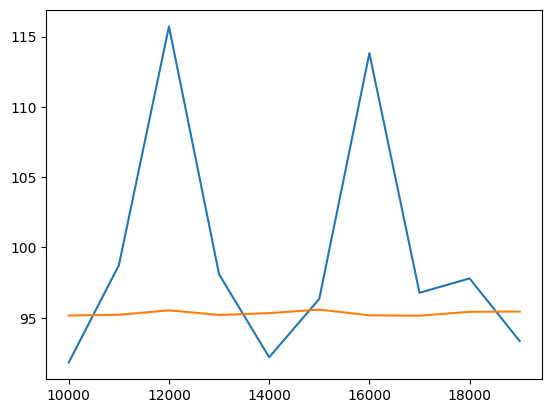

In [12]:
plt.plot(np.arange(10000, 20000, 1000).get(), np.array(normal).get())
print(new)
plt.plot(np.arange(10000, 20000, 1000).get(), np.array(new).get())

In [5]:
from tqdm import tqdm
from scipy.signal import find_peaks

mean_x_dict = {}
temp_dict = {}
temp_list = 10 ** np.linspace(-2, np.log10(2), 50)
for temp_val in temp_list:
    temp_dict[temp_val.item()] = []

for mean_x in np.arange(1, 1.1, 1):
    mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)
    total_delay = []

    energy_grid = np.linspace(0, 10 * temp, 50000)[1:]
    dE = energy_grid[1] - energy_grid[0]

    for i in tqdm(range(500)):
        energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
        time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
    
        peaks, _ = find_peaks(time_delays.get(), height=100)

        peak_vals = energy_grid[peaks]

        new_energies = np.array([])
        insert = np.array([i * dE / 500 for i in range(500)])

        for energy in energy_grid:
            near_peak = False

            diff = np.abs(energy - peak_vals)
            if np.min(diff) < 3 * dE:
                near_peak = True

            if near_peak:
                new_energies = np.append(new_energies, energy + insert)
            else:
                new_energies = np.append(new_energies, energy)

        integral = np.append(new_energies[1:] - new_energies[:-1], dE) * wigner_smith_matrix(new_energies, energy_GOE_mat, np.square(W_mat))

        for temp_val in temp_list:
            temp_dict[temp_val.item()].append(np.sum(integral * relative_MB_weights(temp_val, new_energies)).item())

    mean_x_dict[mean_x.item()] = total_delay

100%|██████████| 500/500 [1:43:32<00:00, 12.42s/it]


In [6]:
import pickle

with open('temp_thermal_delay.pkl', 'wb') as f:
    pickle.dump(temp_dict, f)

[0.01       0.01114191 0.01241422 0.01383182 0.0154113  0.01717113
 0.01913193 0.02131663 0.02375081 0.02646294 0.02948478 0.03285169
 0.03660307 0.04078283 0.04543988 0.05062872 0.05641008 0.06285163
 0.07002874 0.07802542 0.08693525 0.09686251 0.10792337 0.12024729
 0.1339785  0.14927769 0.16632391 0.18531667 0.20647824 0.23005627
 0.25632672 0.28559702 0.31820974 0.35454655 0.39503271 0.44014204
 0.49040247 0.54640221 0.60879663 0.67831596 0.7557738  0.84207666
 0.93823456 1.04537286 1.16474543 1.29774933 1.44594112 1.61105514
 1.79502375 2.        ]
[array(97.38876295), array(97.56804838), array(97.63442568), array(97.60464373), array(97.49552233), array(97.32343489), array(97.1038442), array(96.85094466), array(96.57743035), array(96.29436771), array(96.01113473), array(95.73539861), array(95.4731239), array(95.2286163), array(95.00460901), array(94.8023938), array(94.62199591), array(94.46239205), array(94.32177043), array(94.19782668), array(94.08807652), array(93.99014997), arr

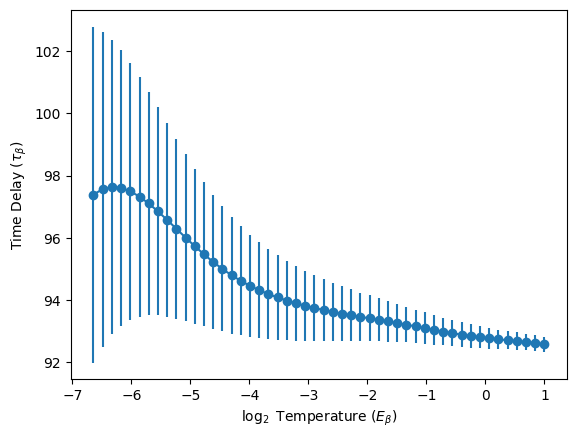

In [28]:
temp_delays = []
temp_stds = []
for temp_val in temp_dict:
    temp_delays.append(np.mean(np.array(temp_dict[temp_val])).get())
    temp_stds.append(np.std(np.array(temp_dict[temp_val])).get() / 20)
temps = np.array([key for key in temp_dict.keys()])
print(temps)
print(temp_delays)
plt.errorbar(np.log2(temps).get(), temp_delays, yerr=temp_stds, fmt='-o')
plt.xlabel(r"$\log_2$ Temperature ($E_\beta$)")
plt.ylabel(r"Time Delay ($\tau_\beta$)")
plt.savefig("delay_vs_temp.pdf")

In [ ]:
import pickle

with open('thermal_delay_precise_fix.pkl', 'wb') as f:
    pickle.dump(total_delay, f)

In [153]:
xs = []
total_delays = []
std = []

for x in mean_x_dict.keys():
    xs.append(x)
    data = np.array(mean_x_dict[x])
    total_delays.append(np.mean(data).get())
    std.append(np.std(data).get())

# plt.plot(xs, total_delays)
print(total_delays[0] / rrkm_c6)
print(std)

0.9907484141850555
[array(10.82518598)]


In [30]:
with open('thermal_delay_precise.pkl', 'rb') as f:
    precise_data = pickle.load(f)
precise_data = np.array(precise_data)

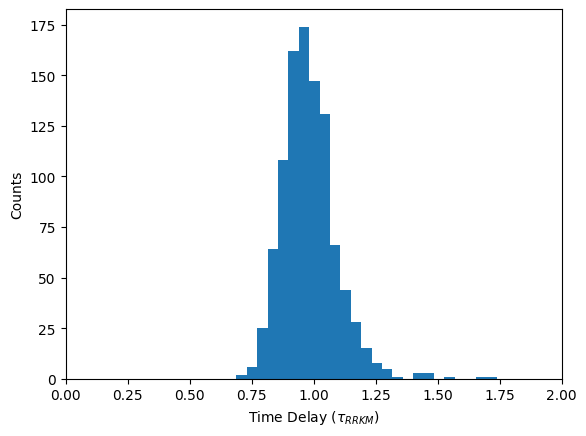

In [38]:
plt.hist(precise_data.get() / rrkm_c6, bins=50)
plt.xlim(0, 2)
plt.xlabel(r"Time Delay ($\tau_{RRKM}$)")
plt.ylabel("Counts")
plt.savefig("dense_thermal.pdf")

In [40]:
hbar = 1
std_k = 1 / 3
std_x = 1 / std_k
print(std_x)
x0 = 200
print(x0)
k0 = 1
print(temp)
print(k0)
print(200 / (2 * k0))

def gaussian_envelope(k):
    normalization = 1 / np.sqrt((std_k * np.sqrt(2 * np.pi)))
    phase = np.exp(-1j * (k - k0) * x0)
    gaussian = np.exp(-((k - k0) / std_k) ** 2 / 4)
    return normalization * gaussian * phase

def wave(t, k, x):
    position = np.exp(1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)

def reflected_wave(t, k, x, r):
    position = np.exp(-1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return r(k) * gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)

3.0
200
1.0
1
100.0


(999,)


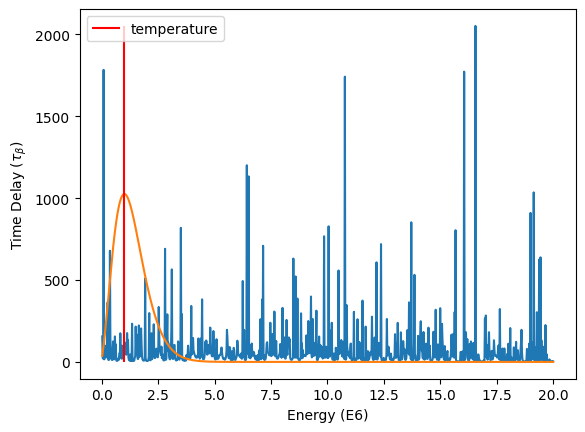

In [41]:
energy_grid = np.linspace(0, 20 * temp, 1000)[1:]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
print(time_delays.shape)
# time_delays = (mean_spacing / 2 / np.pi) * time_delays
plt.plot(energy_grid.get(), time_delays.get())
plt.plot(energy_grid.get(), max(time_delays.get() / np.abs(gaussian_envelope(k0)).get() ** 2 / 2) * np.abs(gaussian_envelope(np.sqrt(energy_grid))).get() ** 2)
plt.vlines(temp, min(time_delays.get()), max(time_delays.get()), colors="red", label="temperature")
plt.legend()
plt.xlabel("Energy (E6)")
plt.ylabel(r"Time Delay ($\tau_\beta$)")
plt.show()

In [138]:
xs = np.append(np.linspace(-1800, 2200, 2001)[:-1], np.linspace(2200, 6200, 1001))
xs = np.linspace(-1800, 2200, 4001)
dx = np.append(xs[1:] - xs[:-1], xs[-1] - xs[-2])
dx = xs[1] - xs[0]

ps = np.linspace(k0 - 4 * std_k, k0 + 4 * std_k, 10001)
dp = ps[1] - ps[0]
print(dp)
ps = ps.reshape((len(ps), 1))

maxt = (100 / k0 / 2) * 10
ts = np.append(np.linspace(0, maxt * 2, 501)[:-1], np.linspace(maxt * 2, maxt * 4, 251))[:500]
dt = np.append(ts[1:] - ts[:-1], ts[-1] - ts[-2])
print(maxt)
time_min = 0
# print(time_min)

# r1 = lambda k : 1 #* S_matrix(k ** 2, energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1))

# psi1 = []
# incoming_envelope = gaussian_envelope(ps) * np.exp(1j * ps * xs) / np.sqrt(2 * np.pi)
# reflected_envelope = r1(ps) * gaussian_envelope(ps) * np.exp(-1j * ps * xs) / np.sqrt(2 * np.pi)
# total_envelope = incoming_envelope + reflected_envelope

# for t in ts:
#     time_evolution = np.exp(1j * ps ** 2 * t)
#     total_wave = total_envelope * time_evolution
#     psi1.append(np.sum(total_wave, axis=0) * dp)
    
# psi1 = np.array(psi1)

# flux_nores = np.sum(np.abs(psi1) ** 2 * dx, axis=1).get()

1.2160000000038806e-05
573.5393346764045


In [182]:
print(ts[490:510])
# print(ps[:10])

[490. 491. 492. 493. 494. 495. 496. 497. 498. 499. 500. 502. 504. 506.
 508. 510. 512. 514. 516. 518.]


0.0
probability 0.012869589022689877
-1772.0


ValueError: operands could not be broadcast together with shapes (1901,) (4001,)

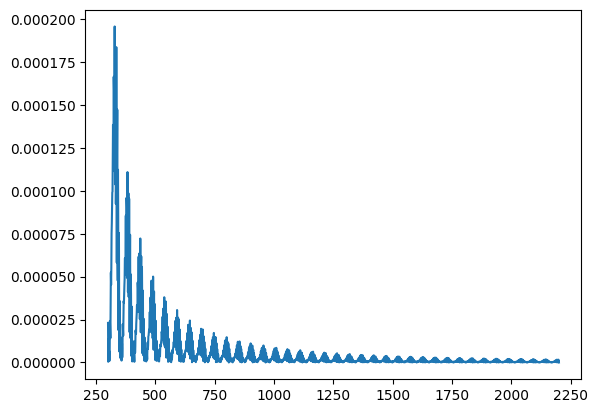

In [183]:
point = 0
psi = psi1
print(ts[point])
plt.plot(xs.get()[2100:], (np.abs(psi[point]).get() ** 2))
print("probability", np.sum(np.abs(psi[point]) ** 2 * dx))
max_point = np.argmax(np.abs(psi[point]) ** 2)
print(xs[max_point])
normalized = np.abs(psi[point]) ** 2 * dx / np.sum(np.abs(psi[point]) ** 2 * dx)
center1 = np.sum(normalized * xs)
print(center1)
# plt.xlim(-1200, -900)
print(ps[np.argmax(np.abs(dp)) + 1])

In [181]:
fluxes = []
fluxes_nores = []

momenta_grid = np.linspace(-0.5, 2.5, 10000)
dmomenta = momenta_grid[1] - momenta_grid[0]

r1 = lambda k : 1 #* S_matrix(k ** 2, energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1))
psi1 = []
normalized_gaussian = gaussian_envelope(ps) / np.sqrt(2 * np.pi)
forward_phase = np.exp(1j * ps * xs)
backward_phase = np.exp(-1j * ps * xs)

incoming_envelope = normalized_gaussian * forward_phase
outgoing_envelope = normalized_gaussian * backward_phase
reflected_envelope_1 = outgoing_envelope
total_envelope_1 = incoming_envelope + reflected_envelope_1

time_evolutions = []
centers1 = []

for t in ts:
    time_evolution = np.exp(1j * ps ** 2 * t)
    time_evolutions.append(time_evolution)
    total_wave_1 = total_envelope_1 * time_evolution
    wave1 = np.sum(total_wave_1 * dp, axis=0)
    psi1.append(wave1[2100:])
    if t == ts[0]:
        index = 1800
        p_flux1 = (np.abs(wave1) ** 2 * dx)[:index]
        center1 = np.sum(p_flux1 * xs[:index]) / np.sum(p_flux1)
        print(np.sum(p_flux1))
        centers1.append(center1)

psi1 = np.array(psi1)
flux_nores = np.sum(np.abs(psi1) ** 2 * dx, axis=1).get()
fluxes_nores.append(flux_nores)
print(flux_nores[-1])

0.5749527986880951
0.5724531309732938


In [131]:
print(flux_nores[-1])

2.2480390315622204e-06


In [188]:
import pickle 
from tqdm import tqdm

spectrum_list = []
data = {}
    # num_sectors = sectors

centers2 = []
total2 = []

for i in tqdm(range(1)):
    energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
    spectrum_list.append((energy_GOE_mat, W_mat, x_actual))
    
    # time_delays = wigner_smith_matrix(np.square(momenta_grid), energy_GOE_mat, np.square(W_mat))
    # peaks, _ = find_peaks(time_delays.get(), height=100)
    # new_momenta = np.array([])
    # peak_vals = momenta_grid[peaks]
    # insert = np.array([i * dmomenta / 100 for i in range(100)])
    # for momenta in momenta_grid:
    #     near_peak = False
    #     diff = np.abs(momenta - peak_vals)
    #     if np.min(diff) < 3 * dmomenta:
    #         near_peak = True
    #     if near_peak:
    #         new_momenta = np.append(new_momenta, momenta + insert)
    #     else:
    #         new_momenta = np.append(new_momenta, momenta)
    # ps = new_momenta[:-1].reshape((-1, 1))
    # print(ps.shape)
    # dp = (new_momenta[1:] - new_momenta[:-1]).reshape((-1, 1))
    
    r2 = lambda k : np.conj(S_matrix((k ** 2), energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1)))

    psi2 = []
    reflected_envelope_2 = r2(ps) * outgoing_envelope
    total_envelope_2 = incoming_envelope + reflected_envelope_2
    
    for time_evolution in time_evolutions:
        total_wave_2 = total_envelope_2 * time_evolution
        wave2 = np.sum(total_wave_2, axis=0) * dp
        psi2.append(wave2[2100:])

        if time_evolution is time_evolutions[0]:
            index = 1800
            p_flux2 = (np.abs(wave2) ** 2 * dx)[:index]
            center2 = np.sum(p_flux2 * xs[:index]) / np.sum(p_flux2)
            centers2.append(center2)
            total2.append(np.sum(p_flux2).item())
        # break
        
    psi2 = np.array(psi2)

    flux = np.sum(np.abs(psi2) ** 2 * dx, axis=1).get()
    fluxes.append(flux)
    # break

save_dict = {"fluxes" : fluxes, "flux_nores" : flux_nores}
data = save_dict
# break

# with open("wavepacket_delay_even_more.pkl", "wb") as f:
#     pickle.dump(data, f)

# print(data)

100%|██████████| 1/1 [00:54<00:00, 54.77s/it]


(-1200.0, 0.0)

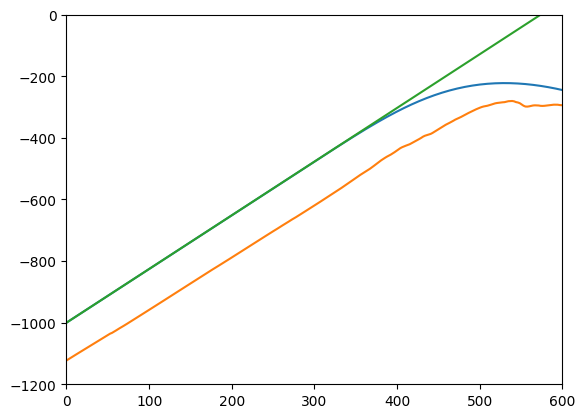

In [87]:
plt.plot(ts.get(), np.array(centers1).get())
plt.plot(ts.get(), np.array(centers2).get())
plt.plot(ts.get(), (ts * 2 * k0 - 1000) .get())
plt.xlim(0, 600)
plt.ylim(-1200, 0)

436


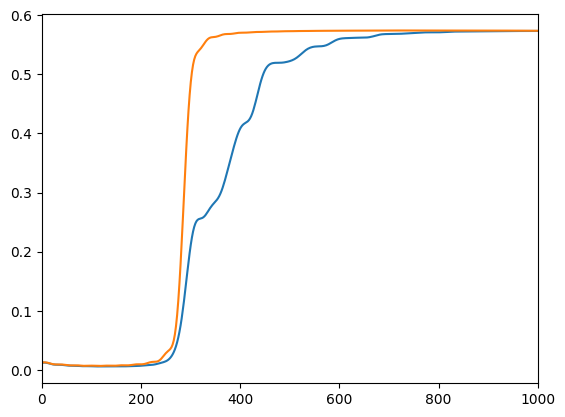

0.5734357369239947


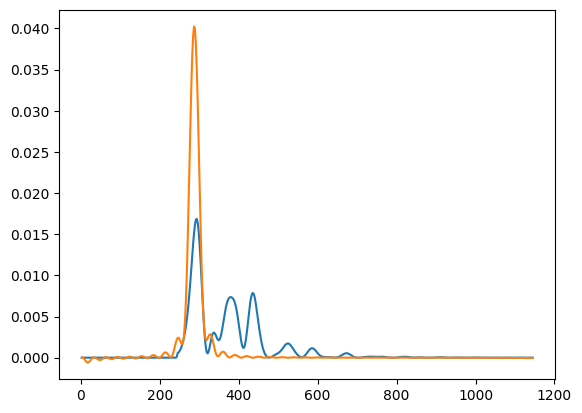

In [193]:
flux = fluxes[1]
flux_nores = save_dict["flux_nores"]
plt.plot(ts.get(), flux)
plt.plot(ts.get(), flux_nores)
plt.xlim(0, 1000)
print(np.argmax(ts > 1000))
# plt.xlim(0, ts[10])
plt.show()

pdf_nores = []
for i in range(len(flux) - 1):
    pdf_nores.append((flux_nores[i + 1] - flux_nores[i]))

pdf = []
current_max = flux[0]
for i in range(len(flux) - 1):
    if flux[i + 1] > current_max:
        pdf.append((flux[i + 1] - current_max))
        current_max = flux[i + 1]
    else:
        pdf.append(0)
plt.plot(ts[1:].get(), np.array(pdf).get())
plt.plot(ts[1:].get(), np.array(pdf_nores).get())
print(current_max)
# plt.xlim(240, 260)
# print(flux_nores[495:505])
# print(np.array(pdf_nores[240:260]))

In [190]:
nores_delay = 0
max_time = 499

for i in range(max_time):
    nores_delay += ((flux_nores[i + 1] - flux_nores[i]) * ts[i])
nores_delay /= max(flux_nores)
print(nores_delay, max(flux_nores))

delays = []
total = []
for flux in fluxes:
    res_delay = 0
    current_max = flux[0]
    for i in range(max_time):
        if flux[i + 1] > current_max:
            res_delay += ((flux[i + 1] - current_max) * ts[i])
            current_max = flux[i + 1]
    total.append(current_max)
    delays.append(res_delay / current_max)
print(delays)
print(len(fluxes))
print(total)

279.7696647491652 0.5742205952420107
[array(292.44029858), array(358.16371322)]
2
[np.float64(0.5608176142224074), np.float64(0.5734357369239947)]


In [191]:
print(centers1, centers2, total2, (center1 - center2) / 2 / k0)
print(delays, nores_delay, delays[1] - nores_delay)

[array(-205.47146582)] [array(-338.13813768)] [0.5765063758994168] 76.08955471192996
[array(292.44029858), array(358.16371322)] 279.7696647491652 78.39404847358742


Text(0, 0.5, 'Counts')

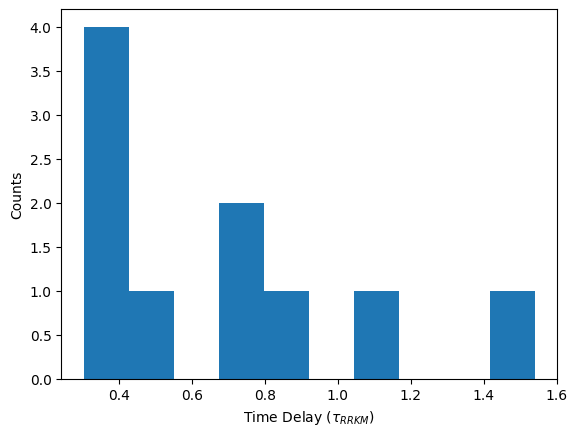

In [100]:
delays = np.array(delays)
plt.hist(((delays - nores_delay).get()) / rrkm_c6, bins=10)
plt.xlabel(r"Time Delay ($\tau_{RRKM}$)")
plt.ylabel("Counts")
# plt.savefig("dense_wavepacket.pdf")

ValueError: x and y must have same first dimension, but have shapes (4001,) and (1901,)

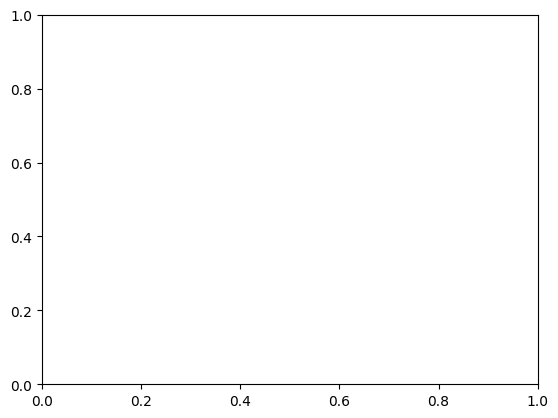

In [ ]:
psis = [psi1, psi2]

import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"

i = 0
fig, ax = plt.subplots()
lines = []
for psi in psis:
    line = ax.plot(xs.get(), np.abs(psi[i]).get() ** 2)[0]
    lines.append(line)
ax.set(xlim=[0, 200])
ax.set(ylim=[0, 0.1])

num = 1000
# line2 = ax.plot([mean1[0] for i in range(num)], [i / num for i in range(num)], color='red')[0]
# line3 = ax.plot([mean1_g0[0] for i in range(num)], [i / num for i in range(num)], color='green')[0]

def update(frame):
    global i
    # update the line plot:
    for j in range(len(psis)):
        lines[j].set_ydata(np.abs(psis[j][i]).get() ** 2)
    # line2.set_xdata([mean1[i] for j in range(num)])
    # line3.set_xdata([mean1_g0[i] for j in range(num)])
    i += 10
    i = i % len(ts)
    return line


ani = animation.FuncAnimation(fig=fig, func=update, frames=20, interval=30)
ani

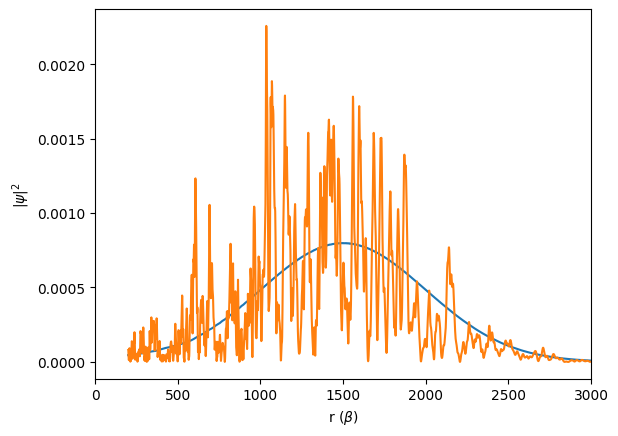

In [54]:
plt.plot(xs.get(), np.abs(psi1[-1]).get() ** 2)
plt.plot(xs.get(), np.abs(psi2[-1]).get() ** 2)
plt.xlim(0, 3000)
plt.xlabel(r"r ($\beta$)")
plt.ylabel(r"$|\psi|^2$")
plt.savefig("wavepacket.pdf")

In [98]:
print(len(spectrum_list))

10


In [109]:
import pickle 
from tqdm import tqdm

data = {}

center_diff = []

xs = np.linspace(-2000, 0, 10001)
dx = np.append(xs[1:] - xs[:-1], xs[-1] - xs[-2])

ps = np.linspace(k0 - 4 * std_k, k0 + 4 * std_k, 10001)
dp = ps[1] - ps[0]
print(dp)
ps = ps.reshape((len(ps), 1))

r1 = lambda k : 1 #* S_matrix(k ** 2, energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1))
normalized_gaussian = gaussian_envelope(ps) / np.sqrt(2 * np.pi)
forward_phase = np.exp(1j * ps * xs)
backward_phase = np.exp(-1j * ps * xs)

incoming_envelope = normalized_gaussian * forward_phase
outgoing_envelope = normalized_gaussian * backward_phase
reflected_envelope_1 = outgoing_envelope
total_envelope_1 = incoming_envelope + reflected_envelope_1
psi1 = np.sum(total_envelope_1, axis=0) * dp
pflux1 = np.abs(psi1) ** 2 * dx
center1 = np.sum(pflux1 * xs) / np.sum(pflux1)

for i in tqdm(range(10)):
    # energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
    energy_GOE_mat, W_mat, x_actual = spectrum_list[i]
      
    r2 = lambda k : np.conj(S_matrix((k ** 2), energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1)))

    reflected_envelope_2 = r2(ps) * outgoing_envelope
    total_envelope_2 = incoming_envelope + reflected_envelope_2
    psi2 = np.sum(total_envelope_2, axis=0) * dp

    pflux2 = np.abs(psi2) ** 2 * dx
    center2 = np.sum(pflux2 * xs) / np.sum(pflux2)

    center_diff.append(center1 - center2)

# save_dict = {"diff" : center_diff}
# data = save_dict
# break

# with open("wavepacket_delay_even_more.pkl", "wb") as f:
#     pickle.dump(data, f)

# print(data)

1.2160000000038806e-05


100%|██████████| 10/10 [00:00<00:00, 453.37it/s]


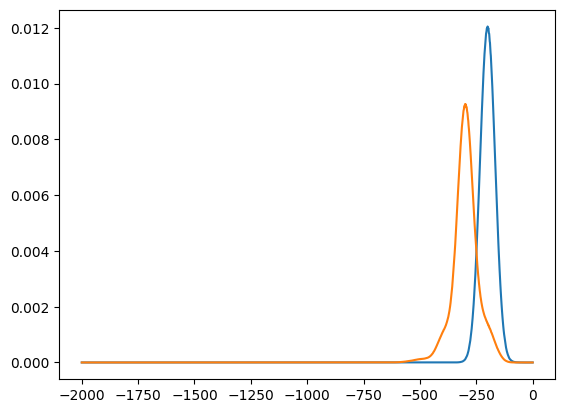

In [107]:
plt.plot(xs.get(), np.abs(psi1).get() ** 2)
plt.plot(xs.get(), np.abs(psi2).get() ** 2)

In [101]:
old_delays = np.array(((delays - nores_delay).get()) / rrkm_c6)
old_delays

array([0.33793683, 0.36356219, 1.53999755, 0.30369935, 0.48490574,
       0.70444408, 0.87927871, 1.0456374 , 0.33834949, 0.70949587])

In [113]:
new_delays = (np.array(center_diff) / k0 / 2 / rrkm_c6)
new_delays

array([0.16657645, 0.20535829, 1.45688937, 0.12923573, 0.32564825,
       0.60219918, 0.66312464, 0.94578469, 0.16374918, 0.60219139])

(array([1., 0., 1., 0., 4., 2., 1., 0., 0., 1.]),
 array([-0.20123189, -0.19120281, -0.18117372, -0.17114463, -0.16111555,
        -0.15108646, -0.14105738, -0.13102829, -0.12099921, -0.11097012,
        -0.10094104]),
 <BarContainer object of 10 artists>)

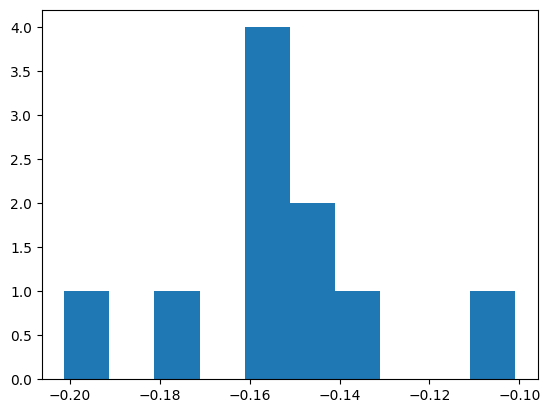

In [23]:
plt.hist((new_delays - old_delays).get())

(array([1., 1., 4., 7., 2., 2., 2., 0., 0., 1.]),
 array([0.58319376, 0.62386338, 0.664533  , 0.70520261, 0.74587223,
        0.78654185, 0.82721147, 0.86788109, 0.90855071, 0.94922032,
        0.98988994]),
 <BarContainer object of 10 artists>)

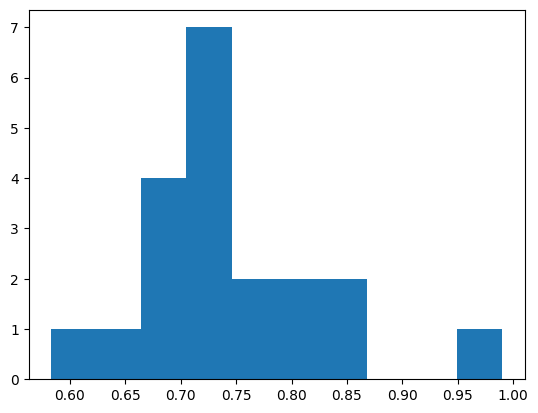

In [130]:
plt.hist((np.array(center_diff) * dx[0] / k0 / 2 / rrkm_c6).get())

-199.99565493636393
-293.92466386796764


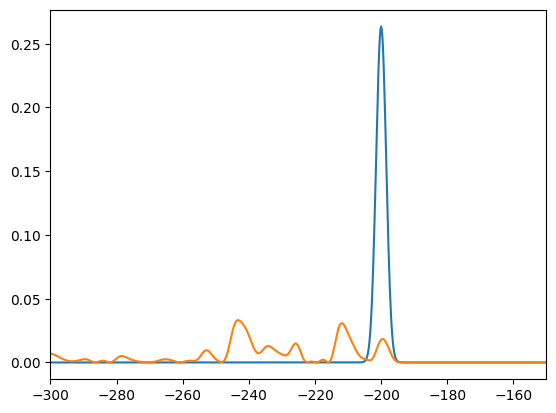

In [35]:
plt.plot(xs.get(), np.abs(psi1).get() ** 2)
plt.plot(xs.get(), np.abs(psi2).get() ** 2)
print(np.sum(np.abs(psi1) ** 2 * xs * dx))
print(np.sum(np.abs(psi2) ** 2 * xs * dx))
plt.xlim(-300, -150)
plt.show()

In [25]:
np.sum(np.abs(psi1) ** 2 * dx)
np.sum(np.abs(psi2) ** 2 * dx)

array(0.9909248)